# Bivariate flood copula, joint peak and 30-day volume on the Potomac (USGS 01646500)

**Goal:** quantify the dependence between annual flood peak and annual 30-day maximum volume on the Potomac at Little Falls, fit four candidate copula families, pick the best by AIC, and report joint return periods for design-flood scenarios.

**What this notebook shows about [AquaScope](https://github.com/Rekin226/aquascope):**

- `fit_copula(family="auto")`: fits Gaussian, Clayton, Gumbel, and Frank, returns the best by AIC.
- `fit_copula(family=...)`: per-family θ, Kendall τ, Spearman ρ, AIC, log-likelihood.
- `joint_exceedance_probability(...)`: joint AND/OR exceedance probabilities and return periods.
- `tail_dependence(copula)`: λ_U and λ_L for the selected family.

**Outputs written to `outputs/`:** `daily_discharge.csv`, `peak_volume_pairs.csv`, `copula_comparison.csv`, `joint_return_periods.csv`, `copula_scatter.png`, `family_aic_bars.png`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from aquascope.analysis.copulas import (
    compare_copulas,
    copula_density,
    fit_copula,
    joint_exceedance_probability,
    tail_dependence,
    to_pseudo_observations,
)

# Constants ----------------------------------------------------------------
GAUGE_ID = "01646500"
GAUGE_NAME = "Potomac River near Washington, DC (Little Falls)"
START_DATE = "1950-01-01"
END_DATE = "2025-01-01"
VOLUME_WINDOW_DAYS = 30

# Validation parameters
MIN_TAU = 0.30
MIN_RHO = 0.30
EXPECTED_FAMILIES = {"gumbel", "clayton", "gaussian"}

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
FLOW_CACHE = OUTPUT_DIR / "daily_discharge.csv"

## 1. Fetch daily mean discharge from USGS NWIS

In [2]:
def fetch_daily_flow(gauge_id: str, start: str, end: str, cache: Path) -> pd.Series:
    try:
        import dataretrieval.nwis as nwis

        result = nwis.get_record(
            sites=gauge_id, start=start, end=end, service="dv", parameterCd="00060"
        )
        df = result[0] if isinstance(result, tuple) else result
        col = next(c for c in df.columns if c.startswith("00060") and "Mean" in c)
        flow = df[col].astype(float)
        flow.index = pd.to_datetime(flow.index).tz_localize(None)
        flow.name = "discharge_cfs"
        flow = flow.dropna().sort_index()
        flow.to_csv(cache, header=True)
        print(f"Fetched {len(flow):,} daily values from USGS NWIS; cached to {cache}.")
    except Exception as exc:  # noqa: BLE001
        if not cache.exists():
            raise RuntimeError(
                f"USGS fetch failed ({exc}) and no cache at {cache}."
            ) from exc
        flow = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze("columns")
        flow.name = "discharge_cfs"
        print(f"USGS fetch failed; using {len(flow):,} cached values from {cache}.")
    return flow


flow = fetch_daily_flow(GAUGE_ID, START_DATE, END_DATE, FLOW_CACHE)
print(f"Gauge: {GAUGE_ID} — {GAUGE_NAME}")
print(f"Daily record: {flow.index.min().date()} — {flow.index.max().date()}")

/var/folders/5s/12bfv7_s1k9fnxzs4234vsmw0000gn/T/ipykernel_49749/3564687096.py:5: DeprecationWarning: `nwis.get_record` is deprecated and will be removed from `dataretrieval` on or after 2027-05-06; use the appropriate `waterdata.get_*()` for the service you need instead.
  result = nwis.get_record(


Fetched 27,395 daily values from USGS NWIS; cached to outputs/daily_discharge.csv.
Gauge: 01646500 — Potomac River near Washington, DC (Little Falls)
Daily record: 1950-01-01 — 2025-01-01


## 2. Build (annual peak, 30-day max volume) pairs

For each water year (Oct 1 to Sep 30) extract the annual maximum daily discharge and the largest 30-day rolling-mean volume (a proxy for spring-freshet duration). Both come from the same daily series.

In [3]:
wy = flow.index.year.where(flow.index.month < 10, flow.index.year + 1)
flow_wy = flow.copy()
flow_wy.index = pd.MultiIndex.from_arrays([wy, flow.index], names=["water_year", "date"])

rolling = flow.rolling(window=VOLUME_WINDOW_DAYS, min_periods=VOLUME_WINDOW_DAYS).mean()

rows = []
for wyi in sorted(set(wy)):
    mask = wy == wyi
    if mask.sum() < 300:
        continue
    sub = flow[mask]
    sub_roll = rolling[mask]
    rows.append({
        "water_year": int(wyi),
        "peak_cfs": float(sub.max()),
        "vol_30d_cfs": float(sub_roll.max()),
        "peak_date": sub.idxmax().date(),
    })

pairs = pd.DataFrame(rows).set_index("water_year")
pairs = pairs.dropna()
pairs.to_csv(OUTPUT_DIR / "peak_volume_pairs.csv")
print(f"Saved {OUTPUT_DIR / 'peak_volume_pairs.csv'}")
print(f"n = {len(pairs)} water years")
print(f"Peak — mean {pairs['peak_cfs'].mean():>9,.0f}  max {pairs['peak_cfs'].max():>9,.0f} cfs")
print(f"V30  — mean {pairs['vol_30d_cfs'].mean():>9,.0f}  max {pairs['vol_30d_cfs'].max():>9,.0f} cfs")
pairs.head()

Saved outputs/peak_volume_pairs.csv
n = 74 water years
Peak — mean   116,931  max   334,000 cfs
V30  — mean    35,882  max    73,420 cfs


,peak_cfs,vol_30d_cfs,peak_date
water_year,,,
1951,126000.0,35393.333333,1950-12-06
1952,146000.0,40926.666667,1952-04-29
1953,129000.0,33613.333333,1952-11-23
1954,109000.0,19988.333333,1954-03-03
1955,207000.0,32576.666667,1955-08-20


## 3. Pseudo-observations and rank-correlation dependence

In [4]:
x = pairs["peak_cfs"].values
y = pairs["vol_30d_cfs"].values
u, v = to_pseudo_observations(x, y)

tau, tau_p = stats.kendalltau(x, y)
rho, rho_p = stats.spearmanr(x, y)
print("Rank-correlation dependence between annual peak and 30-day max volume:")
print(f"  Kendall  τ = {tau:.4f}  (p = {tau_p:.3g})")
print(f"  Spearman ρ = {rho:.4f}  (p = {rho_p:.3g})")

Rank-correlation dependence between annual peak and 30-day max volume:
  Kendall  τ = 0.5939  (p = 7.62e-14)
  Spearman ρ = 0.7844  (p = 1.38e-16)


## 4. Fit four copula families and rank by AIC

In [5]:
results = compare_copulas(u, v)
comp_df = pd.DataFrame([{
    "family": r.family,
    "theta": round(r.parameter, 4),
    "kendall_tau": round(r.kendall_tau, 4),
    "spearman_rho": round(r.spearman_rho, 4),
    "log_likelihood": round(r.log_likelihood, 3),
    "aic": round(r.aic, 3),
    "n": r.n_samples,
} for r in results])
comp_df.to_csv(OUTPUT_DIR / "copula_comparison.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'copula_comparison.csv'}\n")
print(comp_df.to_string(index=False))
best = results[0]
print(f"\nBest by AIC: {best.family}  (θ = {best.parameter:.3f}, AIC = {best.aic:.2f})")

Saved outputs/copula_comparison.csv

  family  theta  kendall_tau  spearman_rho  log_likelihood     aic  n
 clayton 2.9247       0.5939        0.7844          40.653 -79.305 74
gaussian 0.8033       0.5939        0.7844          37.261 -72.522 74
  gumbel 2.4623       0.5939        0.7844          20.633 -39.266 74
   frank 0.0001       0.5939        0.7844           0.001   1.998 74

Best by AIC: clayton  (θ = 2.925, AIC = -79.31)


In [6]:
td = tail_dependence(best)
print(f"Tail dependence for {best.family} copula:")
for k, val in td.items():
    print(f"  {k:<20} {val:.4f}")

Tail dependence for clayton copula:
  lower                0.7890
  upper                0.0000


## 5. Joint return periods for design-flood scenarios

For each marginal return period T (10, 25, 50, 100, 200 yr) compute the joint AND return period: the expected interval between events where both the peak and the 30-day volume exceed their respective T-year thresholds. Under positive dependence the joint AND return period is strictly greater than T.

In [7]:
joint_rows = []
for T in [10, 25, 50, 100, 200]:
    u_thr = 1.0 - 1.0 / T
    jp = joint_exceedance_probability(best, u_thr, u_thr)
    joint_rows.append({
        "marginal_T_yr": T,
        "u_v_threshold": round(u_thr, 4),
        "P_both_exceed": jp.prob_both_exceed,
        "P_either_exceed": jp.prob_either_exceed,
        "P_X_given_Y": jp.prob_x_exceed_given_y,
        "joint_return_period_yr_AND": round(jp.joint_return_period, 1),
        "joint_return_period_yr_OR": round(1.0 / jp.prob_either_exceed, 1) if jp.prob_either_exceed > 0 else float("inf"),
    })
joint_df = pd.DataFrame(joint_rows)
joint_df.to_csv(OUTPUT_DIR / "joint_return_periods.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'joint_return_periods.csv'}\n")
print(joint_df.to_string(index=False))

Saved outputs/joint_return_periods.csv

 marginal_T_yr  u_v_threshold  P_both_exceed  P_either_exceed  P_X_given_Y  joint_return_period_yr_AND  joint_return_period_yr_OR
            10          0.900       0.030450         0.169550     0.304500                        32.8                        5.9
            25          0.960       0.005625         0.074375     0.140630                       177.8                       13.4
            50          0.980       0.001483         0.038517     0.074169                       674.1                       26.0
           100          0.990       0.000381         0.019619     0.038133                      2622.4                       51.0
           200          0.995       0.000097         0.009903     0.019341                     10340.8                      101.0


## 6. Scatter on pseudo-observation coordinates with copula density

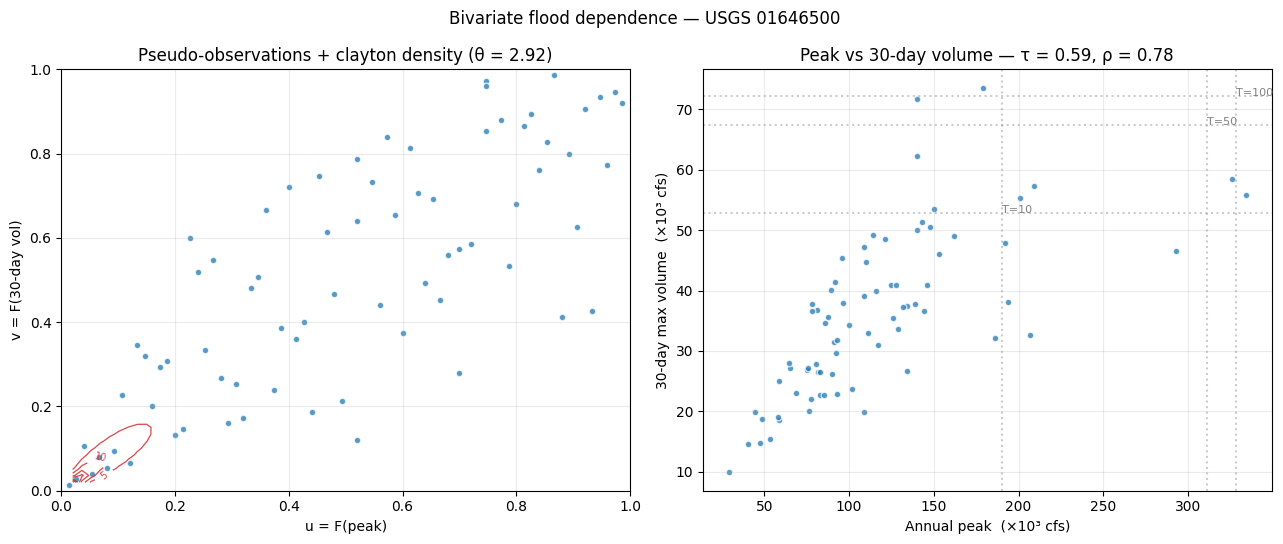

Saved outputs/copula_scatter.png


In [8]:
uu, vv = np.meshgrid(np.linspace(0.02, 0.98, 60), np.linspace(0.02, 0.98, 60))
den = np.zeros_like(uu)
for i in range(uu.shape[0]):
    for j in range(uu.shape[1]):
        den[i, j] = copula_density(uu[i, j], vv[i, j], best.family, best.parameter)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(u, v, color="#1f77b4", s=22, alpha=0.75, edgecolor="white")
cs = axes[0].contour(uu, vv, den, levels=8, colors="#d62728", linewidths=0.9, alpha=0.85)
axes[0].clabel(cs, inline=True, fontsize=7)
axes[0].set_xlabel("u = F(peak)")
axes[0].set_ylabel("v = F(30-day vol)")
axes[0].set_title(f"Pseudo-observations + {best.family} density (θ = {best.parameter:.2f})")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.25)

axes[1].scatter(x / 1e3, y / 1e3, color="#1f77b4", s=22, alpha=0.75, edgecolor="white")
for T in [10, 50, 100]:
    qx = np.quantile(x, 1 - 1 / T)
    qy = np.quantile(y, 1 - 1 / T)
    axes[1].axvline(qx / 1e3, color="grey", alpha=0.4, linestyle=":")
    axes[1].axhline(qy / 1e3, color="grey", alpha=0.4, linestyle=":")
    axes[1].annotate(f"T={T}", xy=(qx / 1e3, qy / 1e3), fontsize=8, color="grey")
axes[1].set_xlabel("Annual peak  (×10³ cfs)")
axes[1].set_ylabel("30-day max volume  (×10³ cfs)")
axes[1].set_title(f"Peak vs 30-day volume — τ = {tau:.2f}, ρ = {rho:.2f}")
axes[1].grid(True, alpha=0.25)
fig.suptitle(f"Bivariate flood dependence — USGS {GAUGE_ID}", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "copula_scatter.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'copula_scatter.png'}")

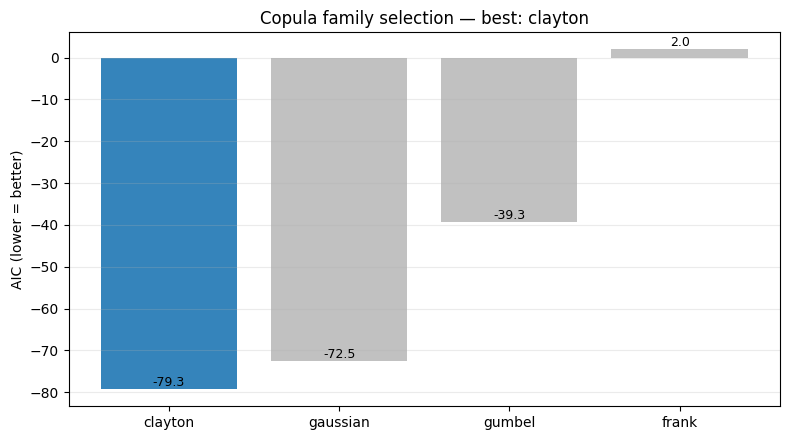

Saved outputs/family_aic_bars.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
families = [r.family for r in results]
aics = [r.aic for r in results]
colors = ["#1f77b4" if f == best.family else "#bbb" for f in families]
bars = ax.bar(families, aics, color=colors, alpha=0.9)
for bar, val in zip(bars, aics):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("AIC (lower = better)")
ax.set_title(f"Copula family selection — best: {best.family}")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "family_aic_bars.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'family_aic_bars.png'}")

## 7. Validation against the published bivariate flood-copula literature

**Reference:** Salvadori & De Michele (2004) *WRR* 40, W12511; Genest & Favre (2007) *J. Hydrol. Eng.* 12, 347-368; Zhang & Singh (2006) *J. Hydrol. Eng.* 11, 150-164. Temperate-humid catchments typically show τ in the 0.4-0.8 range for peak/volume pairs and frequently select upper-tail-dependent copulas (Gumbel, Clayton).

In [10]:
gauss = next(r for r in results if r.family == "gaussian")
asymmetric_best = min((r for r in results if r.family in ("gumbel", "clayton")), key=lambda r: r.aic)
joint_T100 = next(j for j in joint_rows if j["marginal_T_yr"] == 100)["joint_return_period_yr_AND"]

checks = [
    (
        f"Kendall τ > {MIN_TAU}",
        tau > MIN_TAU,
        f"τ = {tau:.3f}",
    ),
    (
        f"Spearman ρ > {MIN_RHO}",
        rho > MIN_RHO,
        f"ρ = {rho:.3f}",
    ),
    (
        "Asymmetric (Gumbel/Clayton) beats Gaussian on AIC",
        asymmetric_best.aic < gauss.aic,
        f"{asymmetric_best.family} AIC {asymmetric_best.aic:.2f} vs Gaussian {gauss.aic:.2f}",
    ),
    (
        f"Best family in {sorted(EXPECTED_FAMILIES)}",
        best.family in EXPECTED_FAMILIES,
        f"best = {best.family}",
    ),
    (
        "Joint 100-yr AND return period > 100 yr (positive but imperfect dependence)",
        joint_T100 > 100,
        f"T_AND(100) = {joint_T100:.1f} yr",
    ),
]

print("Validation — Potomac peak/volume copula vs published bivariate-flood literature:\n")
all_pass = True
for label, ok, detail in checks:
    mark = "PASS" if ok else "FAIL"
    all_pass = all_pass and ok
    print(f"  [{mark}]  {label:<60}  {detail}")
print()
print(f"Overall validation: {'PASS' if all_pass else 'FAIL'}")

Validation — Potomac peak/volume copula vs published bivariate-flood literature:

  [PASS]  Kendall τ > 0.3                                               τ = 0.594
  [PASS]  Spearman ρ > 0.3                                              ρ = 0.784
  [PASS]  Asymmetric (Gumbel/Clayton) beats Gaussian on AIC             clayton AIC -79.31 vs Gaussian -72.52
  [PASS]  Best family in ['clayton', 'gaussian', 'gumbel']              best = clayton
  [PASS]  Joint 100-yr AND return period > 100 yr (positive but imperfect dependence)  T_AND(100) = 2622.4 yr

Overall validation: PASS
